# 01. Dataset Exploration and Preprocessing
In this notebook, we explore the raw Sentinel-2 satellite imagery. Satellite data drastically differs from standard RGB images: it operates in 16-bit depth (values ranging from 0 to 10000+), whereas standard models expect 8-bit tensors [0, 1].

Additionally, raw satellite tiles often contain `NoData` regions (black triangles at the edges of the scanning swath). Feeding these regions into a neural network will severely corrupt the feature extraction process. Here, we demonstrate our `get_smart_roi_crops` algorithm, which finds the intersection of valid data between the "Before" and "After" images.

✅ Знайдено 2 унікальних локацій із парами 'До/Після'.
Location: T36UYA | Before: 20160405T085012 | After: 20190909T083559


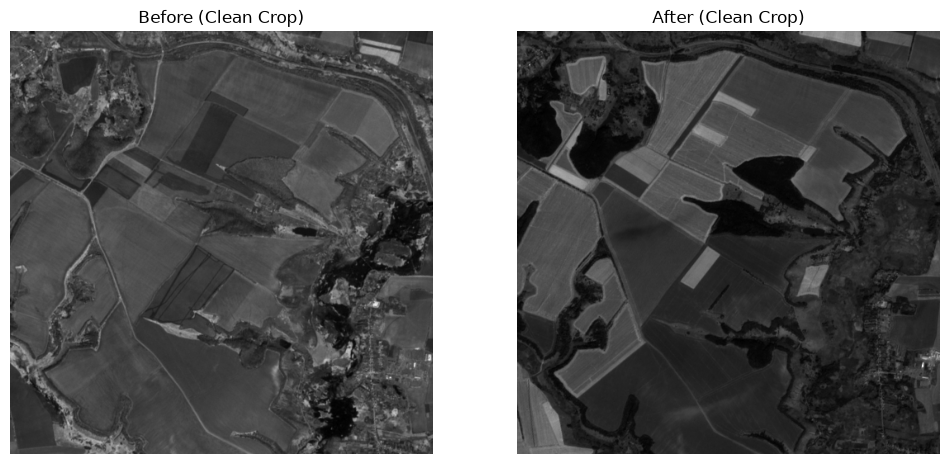

In [1]:
import os
import sys
import rasterio
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data.dataset import PairedDeforestationDataset
from src.data.roi import get_smart_roi_crops

data_dir = os.path.expanduser(r"~\.cache\kagglehub\datasets\isaienkov\deforestation-in-ukraine\versions\1")
dataset = PairedDeforestationDataset(data_dir=data_dir)
pair = dataset.pairs[0]

print(f"Location: {pair['tile_id']} | Before: {pair['date_before']} | After: {pair['date_after']}")

with rasterio.open(pair["before_b04"]) as src_b:
    img_b_full = src_b.read(1)
with rasterio.open(pair["after_b04"]) as src_a:
    img_a_full = src_a.read(1)

valid_crops = get_smart_roi_crops(img_b_full, img_a_full, tile_size=512, num_crops=1)
x, y = valid_crops[0]

img_b_crop = img_b_full[y:y+512, x:x+512]
img_a_crop = img_a_full[y:y+512, x:x+512]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(np.clip(img_b_crop / 3000.0, 0, 1), cmap='gray')
ax[0].set_title("Before (Clean Crop)")
ax[0].axis('off')

ax[1].imshow(np.clip(img_a_crop / 3000.0, 0, 1), cmap='gray')
ax[1].set_title("After (Clean Crop)")
ax[1].axis('off')

plt.show()